# Interior Transforms Lab

Notebook companion to `docs/superpowers/specs/2026-04-26-interior-transforms-lab-design.md`.

Each section corresponds to one cycle of the depth-first plan. New sections are appended as cycles complete; results are written to `benchmarks_cycle1_sorts.csv` (and per-cycle siblings later).

Pipeline being modified (interior only; boundary stays crack-free on global int grid):

```
split bnd/int -> quantize bnd -> SORT interior  <- cycle 1
                              -> TREND_REMOVE   <- cycle 2 (float)
                              -> TRANSFORM      <- cycle 3, 4 (float)
                              -> QUANTIZE (per-level d)
                              -> PACK
```

## Section 0 - Setup

Load Stanford-bunny, generate meshlets, pick a representative full-sized meshlet for diagnostic plots.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa

from reader import Reader
from utils.meshlet_generator import (
    build_adjacency, compute_face_normals, compute_face_centroids,
    generate_meshlets_by_verts, edgebreaker_vertex_order,
)
from utils.boundary_split import (
    identify_boundary_verts, split_meshlet_verts, sort_by_morton,
)
from utils.interior_sorts import sort_interior
from encoder.implementation.meshlet_wavelet import (
    _to_numpy, _global_quantize,
)

np.random.seed(0)
plt.rcParams['figure.dpi'] = 100

model = Reader.read_from_file('assets/stanford-bunny.obj')
verts_np, tris_np = _to_numpy(model)
center = verts_np.mean(axis=0); vc = verts_np - center
scale = float(np.max(np.linalg.norm(vc, axis=1))); vn = vc / scale
precision_error = 0.0005
per_coord_err = precision_error / scale / np.sqrt(3)

global_codes, g_min, g_range, g_bits = _global_quantize(vn, per_coord_err)
tri_adj = build_adjacency(tris_np)
fn = compute_face_normals(vn, tris_np)
fc = compute_face_centroids(vn, tris_np)
meshlets = generate_meshlets_by_verts(tris_np, tri_adj, fn, fc, max_verts=256)
boundary_set = identify_boundary_verts(meshlets, tris_np)

# Pick a representative meshlet (~150-200 interior verts)
candidates = []
for i, ml in enumerate(meshlets):
    vo, _, _ = edgebreaker_vertex_order(ml, tris_np, tri_adj)
    _, _, il, _ = split_meshlet_verts(vo, boundary_set)
    if 150 <= len(il) <= 200:
        candidates.append(i)
chosen = int(np.random.choice(candidates))
ml_tris = meshlets[chosen]
vert_order, _, _ = edgebreaker_vertex_order(ml_tris, tris_np, tri_adj)
_, bnd_local, int_local, _ = split_meshlet_verts(vert_order, boundary_set)

print(f'Mesh: {len(verts_np):,} verts, {len(tris_np):,} tris, {len(meshlets)} meshlets')
print(f'Chose meshlet {chosen}: {len(int_local)} interior verts')

Mesh: 35,947 verts, 69,451 tris, 330 meshlets
Chose meshlet 50: 192 interior verts


## Section 1 - Cycle 1: Alternative interior sorts

**Hypothesis.** Smoother 1D ordering -> smaller deltas -> fewer detail-coefficient bits at the same delta budget.

**Variants.** `morton` (baseline), `eb` (EB-traversal fallthrough = strip-like), `hilbert`, `pca`, `greedy_nn`. Boundary always Morton-sorted; only the interior order varies.

### Sorted-stream overlay

For the chosen meshlet, plot the per-axis 1D sequence under each sort. Smoother lines = better compression downstream.

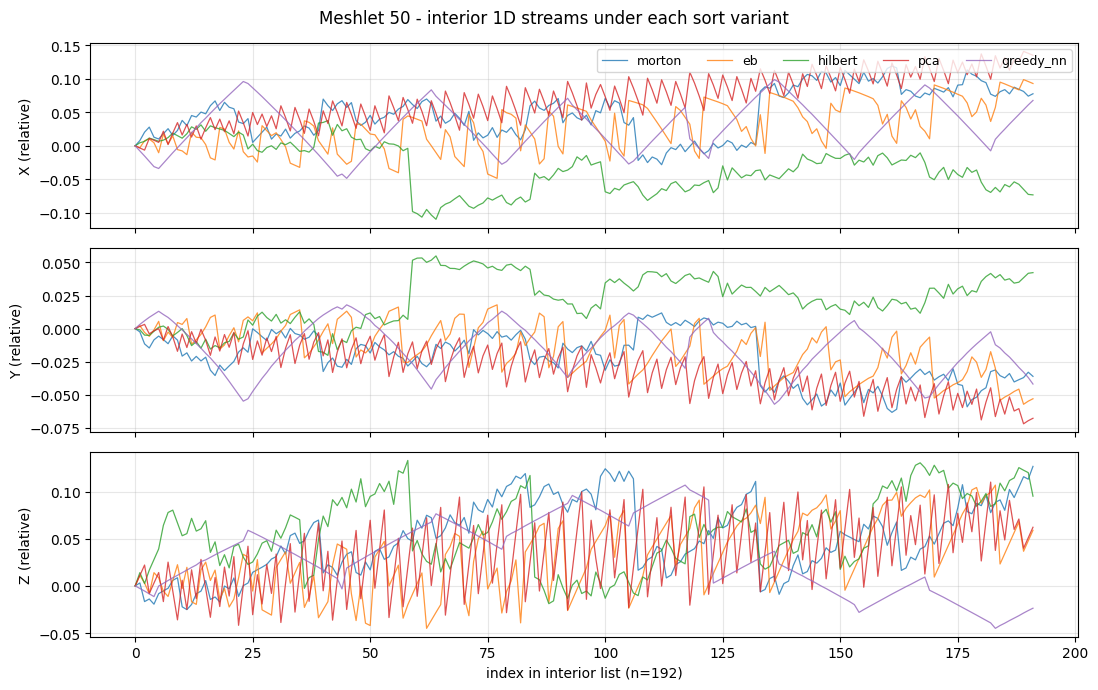

In [2]:
VARIANTS = ['morton', 'eb', 'hilbert', 'pca', 'greedy_nn']

sorted_streams = {}
for v in VARIANTS:
    if v == 'eb':
        # Falls through: keep EB order (no sort)
        idx = list(int_local)
    else:
        idx = sort_interior(v, list(int_local),
                            global_codes=global_codes,
                            vert_pos_float=vn)
    sorted_streams[v] = vn[idx]

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
for d, label in enumerate(['X', 'Y', 'Z']):
    for v in VARIANTS:
        s = sorted_streams[v][:, d]
        axes[d].plot(s - s[0], '-', lw=0.9, alpha=0.8, label=v)
    axes[d].set_ylabel(f'{label} (relative)')
    axes[d].grid(True, alpha=0.3)
axes[0].legend(loc='upper right', ncol=5, fontsize=9)
axes[-1].set_xlabel(f'index in interior list (n={len(int_local)})')
plt.suptitle(f'Meshlet {chosen} - interior 1D streams under each sort variant')
plt.tight_layout()
plt.show()

### Delta-magnitude histograms

Smoother streams produce smaller `|x[i+1] - x[i]|`. Fewer big jumps = less detail-coefficient energy after Haar.

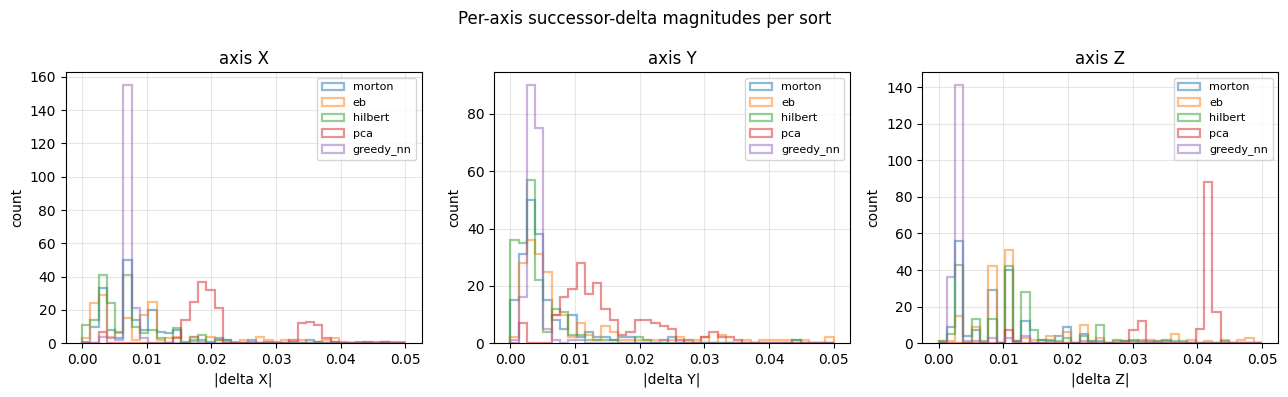


sort          mean |dX|  mean |dY|  mean |dZ|  sum sigma
morton           0.0101     0.0053     0.0108     0.0384
eb               0.0175     0.0092     0.0205     0.0713
hilbert          0.0077     0.0041     0.0130     0.0370
pca              0.0237     0.0145     0.0504     0.0971
greedy_nn        0.0075     0.0038     0.0037     0.0200


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for d, label in enumerate(['X', 'Y', 'Z']):
    bins = np.linspace(0, 0.05, 40)
    for v in VARIANTS:
        s = sorted_streams[v][:, d]
        diffs = np.abs(np.diff(s))
        axes[d].hist(diffs, bins=bins, alpha=0.5, label=v, histtype='step', lw=1.6)
    axes[d].set_xlabel(f'|delta {label}|')
    axes[d].set_ylabel('count')
    axes[d].set_title(f'axis {label}')
    axes[d].grid(True, alpha=0.3)
    axes[d].legend(fontsize=8)
plt.suptitle('Per-axis successor-delta magnitudes per sort')
plt.tight_layout()
plt.show()

print(f'\n{"sort":<12} {"mean |dX|":>10} {"mean |dY|":>10} {"mean |dZ|":>10} {"sum sigma":>10}')
for v in VARIANTS:
    s = sorted_streams[v]
    means = [np.mean(np.abs(np.diff(s[:, d]))) for d in range(3)]
    sig = sum(np.std(np.diff(s[:, d])) for d in range(3))
    print(f'{v:<12} {means[0]:>10.4f} {means[1]:>10.4f} {means[2]:>10.4f} {sig:>10.4f}')

### Aggregate BPV table

Real per-mesh BPV after running `MeshletSplitFloatHaarAMD(sort=...)` end-to-end. Loaded from `benchmarks_cycle1_sorts.csv` (produced by `python test_cycle1_quick.py`).

In [4]:
import csv
import os

if not os.path.exists('benchmarks_cycle1_sorts.csv'):
    print('Run `python test_cycle1_quick.py` first to produce the CSV.')
else:
    with open('benchmarks_cycle1_sorts.csv') as f:
        rows = list(csv.DictReader(f))
    by_model = {}
    for r in rows:
        by_model.setdefault(r['model'], []).append(r)
    for model_name, rs in by_model.items():
        print(f'\n=== {model_name} (n_verts={rs[0]["n_verts"]}) ===')
        baseline = next((float(r['bpv']) for r in rs if r['sort'] == 'morton'), None)
        print(f'{"sort":<12} {"BPV":>8} {"delta vs morton":>18} {"bytes":>12}')
        for r in sorted(rs, key=lambda x: float(x['bpv'])):
            d = float(r['bpv']) - baseline if baseline else 0
            mark = ' <-- best' if r == sorted(rs, key=lambda x: float(x['bpv']))[0] else ''
            print(f'{r["sort"]:<12} {r["bpv"]:>8} {d:>+18.2f} {int(r["total_bytes"]):>12,d}{mark}')


=== bunny (n_verts=2503) ===
sort              BPV    delta vs morton        bytes
greedy_nn       51.13              -0.46       15,998 <-- best
morton          51.59              +0.00       16,141
hilbert         51.62              +0.03       16,151
pca             52.19              +0.60       16,329
eb              52.34              +0.75       16,376

=== stanford-bunny (n_verts=35947) ===
sort              BPV    delta vs morton        bytes
greedy_nn       44.94              -1.25      201,917 <-- best
morton          46.19              +0.00      207,566
hilbert         46.47              +0.28      208,795
pca             46.98              +0.79      211,113
eb              47.63              +1.44      214,023


### Cycle-1 result summary

Run `python test_cycle1_quick.py` to populate the CSV; the cell above pulls per-mesh BPV per sort. Spec success criterion: best sort beats Morton by >= 0.5 BPV on Stanford-bunny.